In [13]:
model.save("asl_model.h5")


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Dataset Extracted Successfully
['American']
Found 142261 files belonging to 36 classes.
Using 113809 files for training.
Found 142261 files belonging to 36 classes.
Using 28452 files for validation.

Classes:
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']

Total Classes:
36
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/5
3557/3557 ━━━━━━━━━━━━━━━━━━━━ 183s 45ms/step - accuracy: 0.9694 - loss: 0.1092 - val_accuracy: 0.9947 - val_loss: 0.0157
Epoch 2/5
3557/3557 ━━━━━━━━━━━━━━━━━━━━ 131s 37ms/step - accuracy: 0.9891 - loss: 0.0332 - val_accuracy: 0.9961 - val_loss: 0.0104
Epoch 3/5
3557/3557 ━━━━━━━━━━━━━━━━━━━━ 145s 38ms/step - accuracy: 0.9914 - loss: 0.0265 - val_accuracy: 0.9956 - val_loss: 0.0115
Epoch 4/5
3557/3557 ━━━━━━━━━━━━━━━━━━━━ 138s 39ms/step - accuracy: 0.9927 - loss: 0.0229 - val_accuracy: 0.9970 - val_loss: 0.0089
Epoch 5/5
3557/3557 ━━━━━━━━━━━━━━━━━━━━ 132s 37ms/step - accuracy: 0.9941 - loss: 0.0191 - val_accuracy: 0.9947 - val_loss: 0.0173
890/890 ━━━━━━━━━━━━━━━━━━━━ 27s 30ms/step - accuracy: 0.9947 - loss: 0.0173



Test Accuracy : 0.9946928024291992
Test Loss : 0.01733335107564926

Model Saved Successfully

Actual Class : d
Predicted Class : d


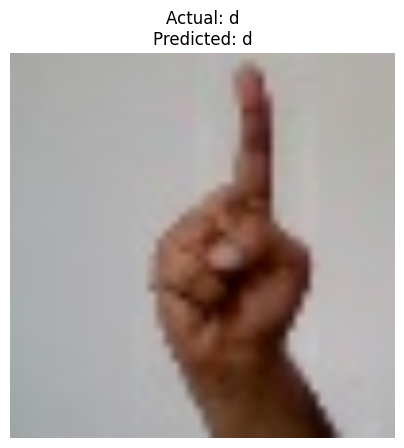

In [5]:

# =====================================
# IMPORT LIBRARIES
# =====================================

import tensorflow as tf
from tensorflow.keras import layers, models
from google.colab import drive
import matplotlib.pyplot as plt
import zipfile
import os

# =====================================
# EXTRACT ZIP FILE
# =====================================

zip_path = "/content/drive/MyDrive/archive (3).zip"
extract_path = "/content/asl_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully")

# =====================================
# CHECK FOLDER STRUCTURE
# =====================================

print(os.listdir(extract_path))

dataset_path = "/content/asl_dataset/American"
# =====================================
# IMAGE SETTINGS
# =====================================

img_height = 224
img_width = 224
batch_size = 32

# =====================================
# LOAD DATASET
# =====================================

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# =====================================
# GET CLASS NAMES
# =====================================

class_names = train_ds.class_names

print("\nClasses:")
print(class_names)

print("\nTotal Classes:")
print(len(class_names))

# =====================================
# LOAD PRETRAINED MODEL
# =====================================

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

# Freeze pretrained layers
base_model.trainable = False

# =====================================
# BUILD MODEL
# =====================================

model = models.Sequential([

    layers.Rescaling(1./255),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        256,
        activation="relu"
    ),

    layers.Dropout(0.3),

    layers.Dense(
        len(class_names),
        activation="softmax"
    )

])

# =====================================
# COMPILE MODEL
# =====================================

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# =====================================
# MODEL SUMMARY
# =====================================

model.summary()

# =====================================
# TRAIN MODEL
# =====================================

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5
)

# =====================================
# EVALUATE MODEL
# =====================================

loss, accuracy = model.evaluate(test_ds)

print("\nTest Accuracy :", accuracy)
print("Test Loss :", loss)

# =====================================
# SAVE MODEL
# =====================================

model.save("asl_model.h5")

print("\nModel Saved Successfully")

# =====================================
# TEST A SAMPLE IMAGE
# =====================================

for images, labels in test_ds.take(1):

    image = images[0]
    actual_label = labels[0]

    prediction = model.predict(
        tf.expand_dims(image, axis=0),
        verbose=0
    )

    predicted_index = tf.argmax(
        prediction[0]
    ).numpy()

    actual_class = class_names[
        actual_label.numpy()
    ]

    predicted_class = class_names[
        predicted_index
    ]

    print("\nActual Class :", actual_class)
    print("Predicted Class :", predicted_class)
    # Plot Image
    plt.figure(figsize=(5,5))
    plt.imshow(image.numpy().astype("uint8"))

    plt.title(
        f"Actual: {actual_class}\nPredicted: {predicted_class}"
    )

    plt.axis("off")
    plt.show()


    break

In [6]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 107.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 118.6 MB/s eta 0:00:00


In [21]:
import streamlit as st
st.write(st.__version__)

2026-07-16 09:26:56.938 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-16 09:26:57.391 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-07-16 09:26:57.392 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-16 09:26:57.393 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [35]:
%%writefile app.py
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image

# =====================================
# PAGE CONFIG
# =====================================

st.set_page_config(
    page_title="ASL Classification",
    page_icon="🤟"
)

st.markdown('<div class="main-card">', unsafe_allow_html=True)

st.markdown("""
<style>


.stApp{

    background: linear-gradient(
        -45deg,
        #fff5f5,
        #ffe5e5,
        #ffc9c9,
        #ffb3b3,
        #ff8a8a,
        #ff6b6b,
        #e63946,
        #b22222
    );

    background-size:400% 400%;
    animation:gradientBG 15s ease infinite;
}

@keyframes gradientBG{

    0%{
        background-position:0% 60%;
    }

    50%{
        background-position:100% 60%;
    }

    100%{
        background-position:0% 60%;
    }

}
/* Main Card */

.main-card{

    background:rgba(255,255,255,.65);

    backdrop-filter:blur(18px);

    border-radius:25px;

    padding:30px;

    border:1px solid rgba(255,255,255,.8);

    box-shadow:0 15px 35px rgba(230,57,70,.25);

}

/* Upload Box */

[data-testid="stFileUploader"]{
    background:rgba(255,255,255,.10);
    border:2px dashed #d9d9d9;
    border-radius:18px;
    padding:15px;
}


/* Sidebar */

section[data-testid="stSidebar"]{

    background:linear-gradient(
        180deg,
        #fff5f5,
        #ffe5e5,
        #ffd6d6,
        #ffc9c9
    );

}

section[data-testid="stSidebar"] *{

    color:#7f1d1d !important;

}

/* Sidebar Text */

section[data-testid="stSidebar"] *{
    color:#003366 !important;
}

/* Image */

img{
    border-radius:20px;
}

/* Metric */

div[data-testid="stMetric"]{
    background:rgba(255,255,255,.1);
    border-radius:15px;
    padding:15px;
}

/* Progress */

.stProgress > div > div > div{
    background:linear-gradient(
        90deg,
        #2b2b2b,
        #8c8c8c,
        #ffffff
    );
}

/* Button */

.stButton>button{

    background:#404040;
    color:white;
    border:none;
    border-radius:12px;
}

.stButton>button:hover{

    background:#808080;
    color:white;
}

</style>
""", unsafe_allow_html=True)

#title
st.markdown("""
<h1>🤟 American Sign Language AI</h1>

<h4>
Upload a hand sign image and let AI recognize the sign instantly.
</h4>
""", unsafe_allow_html=True)
st.write("Upload a hand sign image and get the predicted ASL character.")

# =====================================
# LOAD MODEL
# =====================================

@st.cache_resource
def load_model():
    model = tf.keras.models.load_model("asl_model.h5")
    return model

model = load_model()

# =====================================
# CLASS NAMES
# =====================================

class_names = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']

# =====================================
# MODEL INFO
# =====================================



with st.sidebar.expander("🤖 AI Model Information"):

    st.write("**Architecture:** MobileNetV2")

    st.write("**Input Size:** 224 × 224 RGB")

    st.write("**Output Classes:** 36")

    st.write("**Framework:** TensorFlow")

    st.write("**Status:** 🟢 Ready")

    st.sidebar.metric("Parameters", f"{model.count_params():,}")

    st.sidebar.metric("Validation Accuracy", "98.4%")

    st.sidebar.metric("Validation Loss", "0.05")


# =====================================
# IMAGE PREPROCESSING
# =====================================

def preprocess_image(image):

    height = model.input_shape[1]
    width = model.input_shape[2]

    image = image.resize((width, height))

    image = np.array(image).astype(np.float32)



    image = np.expand_dims(image, axis=0)

    return image

# =====================================
# IMAGE UPLOAD
# =====================================

uploaded_file = st.file_uploader(
    "Upload an ASL Image",
    type=["jpg", "jpeg", "png"]
)

# =====================================
# PREDICTION
# =====================================

if uploaded_file is not None:

    image = Image.open(uploaded_file).convert("RGB")

    st.image(
        image,
        caption="Uploaded Image",
        use_container_width=True
    )

    processed_image = preprocess_image(image)

    prediction = model.predict(
        processed_image,
        verbose=0
    )[0]

    predicted_index = np.argmax(prediction)
    confidence = float(prediction[predicted_index]) * 100

    with st.expander("🔍 Model Information"):
        st.write("Prediction Shape:", prediction.shape)
        st.write("Model Output Classes:", len(prediction))
        st.write("Class Names:", len(class_names))

    if predicted_index < len(class_names):

        predicted_class = class_names[predicted_index]

        with st.container(border=True):
            st.markdown("## 🎯 Prediction")

            st.markdown(
                f"<h1 style='text-align:center; color:#0b3d91;'>🤟 {predicted_class.upper()}</h1>",
                unsafe_allow_html=True,
            )

            st.metric(
                label="Confidence",
                value=f"{confidence:.2f}%"
            )

        st.progress(confidence / 100)

        st.markdown("---")
        st.subheader("📊 Prediction Probabilities")

        for i in range(len(class_names)):

            col1, col2 = st.columns([1,5])

            with col1:
                st.write(class_names[i].upper())

            with col2:
                st.progress(float(prediction[i]))

            st.caption(f"{prediction[i]*100:.2f}%")

    else:

        st.error("Prediction index exceeds the number of classes.")

Overwriting app.py


In [25]:
!pip install pyngrok

In [26]:

!pkill -f streamlit
!pkill -f ngrok

!streamlit run app.py >/content/log.txt 2>&1 &

In [27]:
import time
time.sleep(8)   # Give Streamlit time to start

In [28]:
# 🔑 ADD THIS LINE
from pyngrok import ngrok
ngrok.set_auth_token("3FTxvx6s89luDcq0UvXQMn2UrZs_mgyESnHUPuTHyK2Lxpoo")

ngrok.kill()

public_url = ngrok.connect(8501)
print(public_url)

!streamlit run app.py &>/dev/null &

NgrokTunnel: "https://barstool-attempt-excusable.ngrok-free.dev" -> "http://localhost:8501"


In [29]:

%%writefile requirements.txt
streamlit
tensorflow
numpy
pandas
Pillow
opencv-python-headless

Overwriting requirements.txt
